# Censo porcino UE — histórico y proyección 2030

El **forecast** de censo porcino a 2030 desagregado por
país es — una **extrapolación de tendencia** construida a partir del
histórico Eurostat, como base vemos un drececimiento del censo en los paises Europeos por diferentes politicas tomandas por cada Gobierno. Para 2030, Algunos paises de la UE consolidará una tendencia a la baja en el consumo interno, condicionada por factores demográficos y políticas verdes, esas medidas seran aprovechadas por Espana ya que tomara un papel como mayor productor en 2030.

## Datos reales (Eurostat, dic. 2024)

| País | Censo 2024 (cabezas) | Variación 10 años | Censo 2023→2024 |
|---|---|---|---|
| UE-27 total | 132,1 M | -6 % (2013→2023), -8,1 % (2014→2024) | -0,5 % |
| **España** | **34,5 M (26,2 % UE)** | **+35,13 %** (2013→2023) | +700k |
| Alemania | 21,2 M | -25 % | +70k |
| Francia | 11,7 M | -12 % | ~estable |
| Dinamarca | 11,5 M | -8 % | +200k |
| Países Bajos | 10,1 M | -13 % | -200k |

**Aragón (región piloto del TFM): 9,9 M cabezas — 7,5 % del total UE-27,
la mayor región NUTS2 de toda la Unión Europea.** Cataluña es la 2ª (8,0 M).
El clúster Aragón + Cataluña + Castilla y León concentra una fracción muy
relevante del censo porcino europeo.

España es el único gran productor con tendencia positiva sostenida; el resto
de la UE decrece de forma consistente.

## Configuración y datos de anclaje

In [1]:
from dataclasses import dataclass
import pandas as pd
import matplotlib.pyplot as plt

''' Datos del Eurostat(cabezas, miles). Año base y año reciente por país'''

ANCHOR_DATA = {
    # país: (año_base, censo_año_base_miles, año_reciente, censo_año_reciente_miles)
    "España":        (2014,  29200, 2024, 34500),
    "Alemania":      (2014,  28000, 2024, 21200),
    "Francia":       (2014,  13200, 2024, 11700),
    "Dinamarca":     (2014,  12300, 2024, 11500),
    "Países Bajos":  (2014,  11800, 2024, 10100),
    "UE-27 (total)": (2014, 143850, 2024, 132100),
}

REGION_ARAGON = {
    "región": "Aragón (ES)",
    "censo_2024_miles": 9900,
    "share_UE_2024": 0.075,  # 7.5% del total UE-27 paises Eurostat
    "fuente": "Eurostat, Agriculture statistics at regional level (dic. 2024)",
}

## Censo total vs. cerdas reproductoras

España 2025: censo total **+3,6 %**, pero cerdas reproductoras **-5 %**
(más productividad por cerda). Si la regresión de Bloque 1
usa nº de cerdas como proxy de purín/feedstock, se infraestima la
producción de biometano real. **Usar censo total** — es la variable
correcta para volumen de purín disponible.

La baja de censo de reproductodas es por mejoras geneticas, es decir, animales mas productivos, mejores controloes sanitarios y menor mortalidades, lo que hace necesitar menos cerdas para la generacion de lechones

##  Proyección a 2030, extrapolando CARG

In [2]:
@dataclass
class ProyeccionPais:
    pais: str
    censo_2024_miles: float
    cagr_2014_2024: float
    censo_2030_miles: float


def calcular_cagr(censo_inicial: float, censo_final: float, años: int) -> float:
    """CAGR = (final/inicial)^(1/años) - 1"""
    if censo_inicial <= 0 or años <= 0:
        raise ValueError("censo_inicial y años deben ser positivos")
    return (censo_final / censo_inicial) ** (1 / años) - 1


def proyectar_2030(anchor_data: dict, año_objetivo: int = 2030) -> pd.DataFrame:
    """
    Extrapola el censo a año_objetivo aplicando el CAGR histórico
    observado entre año_base y año_reciente.

    No aplica ningún ajuste estructural (PPA, normativa de bienestar
    animal, Pacto Verde, etc.) — extrapolación pura de tendencia.
    """
    filas = []
    for pais, (año_base, censo_base, año_reciente, censo_reciente) in anchor_data.items():
        años_historicos = año_reciente - año_base
        cagr = calcular_cagr(censo_base, censo_reciente, años_historicos)
        años_proyeccion = año_objetivo - año_reciente
        censo_2030 = censo_reciente * (1 + cagr) ** años_proyeccion
        filas.append(
            ProyeccionPais(
                pais=pais,
                censo_2024_miles=censo_reciente,
                cagr_2014_2024=cagr,
                censo_2030_miles=censo_2030,
            )
        )

    df = pd.DataFrame([f.__dict__ for f in filas])
    df["variacion_2024_2030_pct"] = (
        df["censo_2030_miles"] / df["censo_2024_miles"] - 1
    ) * 100
    return df.sort_values("censo_2024_miles", ascending=False).reset_index(drop=True)


def graficar_proyeccion(df: pd.DataFrame, ruta_salida: str = None,
                          pais_resaltado: str = "España") -> None:
    """
    Barras agrupadas: censo 2024 vs proyección 2030 (extrapolación CAGR).
    `pais_resaltado` se pinta en dos tonos de verde (en vez de azul/naranja)
    y con borde marcado, para que su trayectoria destaque del resto.
    """
    fig, ax = plt.subplots(figsize=(9, 5.5))
    x = range(len(df))
    width = 0.35

    color_2024 = ["#4C72B0" if pais == pais_resaltado else "#4C72B0" for pais in df["pais"]]
    color_2030 = ["#DD8452" if pais == pais_resaltado else "#DD8452" for pais in df["pais"]]
    borde = ["black" if pais == pais_resaltado else "none" for pais in df["pais"]]
    grosor_borde = [1.6 if pais == pais_resaltado else 0 for pais in df["pais"]]

    ax.bar([i - width / 2 for i in x], df["censo_2024_miles"] / 1000, width=width,
           label="2024 (Eurostat)", color=color_2024, edgecolor=borde, linewidth=grosor_borde)
    ax.bar([i + width / 2 for i in x], df["censo_2030_miles"] / 1000, width=width,
           label="2030 (extrapolación CAGR)", color=color_2030, edgecolor=borde, linewidth=grosor_borde)

    ax.set_xticks(list(x))
    etiquetas = ax.set_xticklabels(df["pais"], rotation=20, ha="right")
    for etiqueta, pais in zip(etiquetas, df["pais"]):
        if pais == pais_resaltado:
            etiqueta.set_fontweight("bold")
            etiqueta.set_color("#C30B05")

    ax.set_ylabel("Millones de cabezas")
    ax.set_title("Censo porcino UE — histórico 2024 vs extrapolación 2030\n"
                  "(extrapolación de tendencia)", fontsize=10)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    for i, row in df.iterrows():
        ax.annotate(f"{row['variacion_2024_2030_pct']:+.1f}%",
                     (i, max(row["censo_2024_miles"], row["censo_2030_miles"]) / 1000 + 0.5),
                     ha="center", fontsize=8,
                     fontweight="bold" if row["pais"] == pais_resaltado else "normal")

    fig.tight_layout()
    if ruta_salida:
        fig.savefig(ruta_salida, dpi=150)
    plt.show()


## Ejecución

In [3]:
df_proyeccion = proyectar_2030(ANCHOR_DATA)

df_print = df_proyeccion.copy()
df_print["cagr_2014_2024"] = (df_print["cagr_2014_2024"] * 100).map(lambda v: f"{v:+.2f}%")
df_print["censo_2024_miles"] = df_print["censo_2024_miles"].map(lambda v: f"{v:,.0f}")
df_print["censo_2030_miles"] = df_print["censo_2030_miles"].map(lambda v: f"{v:,.0f}")
df_print["variacion_2024_2030_pct"] = df_print["variacion_2024_2030_pct"].map(lambda v: f"{v:+.1f}%")
df_print

,pais,censo_2024_miles,cagr_2014_2024,censo_2030_miles,variacion_2024_2030_pct
0,UE-27 (total),"132,100",-0.85%,"125,516",-5.0%
1,España,"34,500",+1.68%,"38,131",+10.5%
2,Alemania,"21,200",-2.74%,"17,941",-15.4%
3,Francia,"11,700",-1.20%,"10,883",-7.0%
4,Dinamarca,"11,500",-0.67%,"11,045",-4.0%
5,Países Bajos,"10,100",-1.54%,"9,200",-8.9%


Aragón (región): 9,900 miles cabezas, 7.5% del total UE-27.


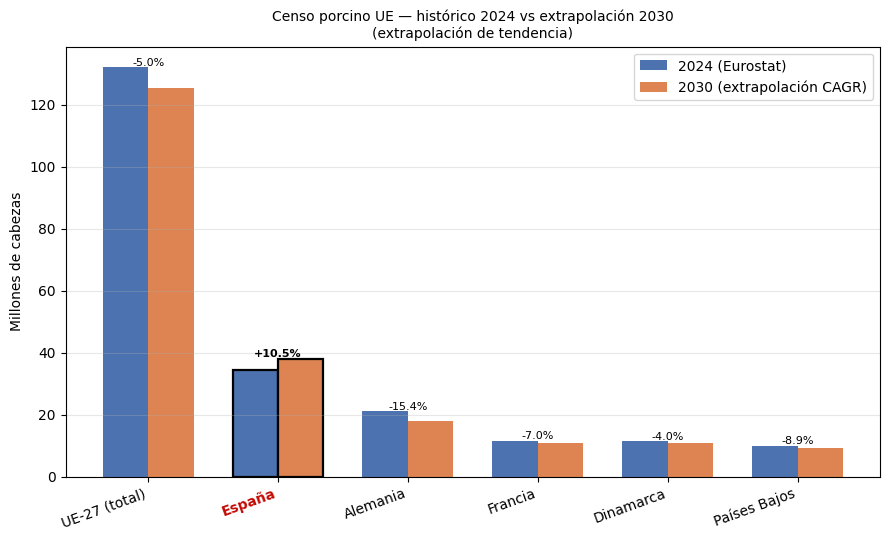

  Nota: España cuenta con un crecimieto anual 'CARG' de +1.68% por año.


In [4]:
print(f"Aragón (región): {REGION_ARAGON['censo_2024_miles']:,} miles cabezas, "
      f"{REGION_ARAGON['share_UE_2024']*100:.1f}% del total UE-27.")

graficar_proyeccion(df_proyeccion)
print(f"  Nota: España cuenta con un crecimieto anual 'CARG' de {df_print.iloc[1]['cagr_2014_2024']} por año.")